
# BioTransit AI — CDR Software MVP v2
### Literature-informed exposure-risk decision layer

**Amaç:** Ham sensör benzeri zaman serisini gönderi bazında özetleyip, sıcaklık + süre + titreşim + darbe geçmişini birlikte kullanan bir **LOW / MEDIUM / HIGH exposure-risk** prototipi göstermek.

> **Bilimsel sınır — kritik:** Bu notebook gerçek biyolojik aktiviteyi tahmin etmez. Risk etiketleri literature-informed **sentetik simülasyon etiketleridir**. Mevcut sonuçlar yalnızca yazılım pipeline'ının çalıştığını ve çok değişkenli maruziyet bilgisini işleyebildiğini gösterir. Gerçek `residual_activity_%` ground-truth'u sonraki PoC aşamasında HRP assay ile üretilecektir.

### Jüri için 20 saniyelik okuma
1. Ham sensör akışı okunur.
2. Gönderi başına termal ve mekanik maruziyet feature'ları **kod içinde çıkarılır**.
3. Risk skoru / scenario gibi sentetik üretim kolonları modele **verilmez**.
4. Random Forest; dummy, basit threshold ve multivariate logistic baseline'larla karşılaştırılır.
5. Sonuçlar tek split yerine **5-fold cross-validation** ile de kontrol edilir.
6. Ayrı bir scenario-holdout testi, sentetik verinin gerçek dünya genellemesi olmadığını açıkça gösterir.



## 1. Veri kökeni ve literatür mantığı

Bu dataset gerçek assay verisi değildir. Literatür burada **çıktı etiketi üretmek için biyolojik gerçeklik iddiası olarak değil**, gerçekçi giriş aralıkları ve feature tasarımı için kullanılmıştır.

- **Siska et al., 2020 — Journal of Pharmaceutical Sciences**  
  Gerçek parcel gönderilerinde GPS + sıcaklık + shock kaydı; yaklaşık 8–36 G shock ve gönderi başına 40'a kadar olay. Sadece benzer shock/drop uygulamak gerçek shipment etkisini tam açıklamamıştır.  
  DOI: `10.1016/j.xphs.2019.10.064`

- **Kizuki et al., 2023 — Journal of Pharmaceutical Sciences**  
  Tri-axial vibration altında frequency + acceleration kombinasyonlarının protein aggregation ile non-linear ilişkisini inceler.  
  DOI: `10.1016/j.xphs.2022.09.022`

- **Zhu et al., 2026 — International Journal of Pharmaceutics**  
  Nivolumab üzerinde 8 / 63 / 125 Hz ve farklı sürelerde drone-vibration benzeri koşullar; titreşimin tek başına otomatik olarak hasar anlamına gelmediğini destekler.

- **Wang et al., 2025 — Molecules**  
  HRP activity'nin temperature/time ile ölçülebilir biyolojik endpoint olduğunu gösterir. 60°C verileri **2–8°C cold-chain koşullarına extrapolate edilmez**.  
  DOI: `10.3390/molecules30224374`

**Önemli:** 8°C ve 2 g gibi eşikler bu simülasyonda feature engineering / operasyonel referans amaçlıdır; evrensel HRP hasar eşikleri değildir.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, LeaveOneGroupOut
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
RAW_FILE = Path("BioTransit_sensor_timeseries.csv")
SHIPMENT_FILE = Path("BioTransit_literature_informed_shipments.csv")

missing = [str(p) for p in [RAW_FILE, SHIPMENT_FILE] if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Eksik dosya(lar): " + ", ".join(missing) +
        "\nColab kullanıyorsanız iki CSV dosyasını sol panelden yükleyin."
    )

raw = pd.read_csv(RAW_FILE)
shipments_reference = pd.read_csv(SHIPMENT_FILE)

print(f"Sensor rows : {len(raw):,}")
print(f"Shipments   : {shipments_reference['shipment_id'].nunique():,}")
print(f"Scenarios   : {shipments_reference['scenario'].nunique()}")


Sensor rows : 97,598
Shipments   : 600
Scenarios   : 7



## 2. Raw sensör akışından gerçek feature engineering

Bu sürümde model hazır feature tablosunu körlemesine kullanmıyor. Feature'lar doğrudan `BioTransit_sensor_timeseries.csv` içinden yeniden hesaplanıyor.

Çıkarılan özetler:
- sıcaklık: mean / max / variability / 8°C üstü süre / thermal AUC,
- mekanik maruziyet: mean-max RMS acceleration / 2 g üstü süre / vibration dose,
- frekans: mekanik maruziyet dönemindeki temsilci frekans,
- shock: event count / 20 g üstü event / max / mean shock.

`scenario`, `literature_informed_risk_score` ve `simulation_integrity_proxy` **model input değildir**.


In [2]:

def extract_shipment_features(raw_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for shipment_id, x in raw_df.groupby("shipment_id", sort=False):
        x = x.sort_values("elapsed_min").copy()

        diffs = np.diff(x["elapsed_min"].to_numpy())
        dt_min = float(np.median(diffs)) if len(diffs) else 10.0

        shock_events = x.loc[x["shock_peak_g"] > 0, "shock_peak_g"]
        vibration_window = x.loc[x["accel_rms_g"] > 2, "vibration_freq_hz"]

        # If a clearly elevated vibration window exists, use its median frequency.
        # Otherwise use an acceleration^2-weighted frequency summary.
        if len(vibration_window):
            dominant_freq = float(vibration_window.median())
        else:
            w = np.maximum(x["accel_rms_g"].to_numpy(), 1e-6) ** 2
            dominant_freq = float(
                np.average(x["vibration_freq_hz"].to_numpy(), weights=w)
            )

        rows.append({
            "shipment_id": shipment_id,
            "duration_h": len(x) * dt_min / 60.0,
            "mean_temp_c": x["temperature_c"].mean(),
            "max_temp_c": x["temperature_c"].max(),
            "temp_sd_c": x["temperature_c"].std(ddof=0),
            "time_above_8c_min": (x["temperature_c"] > 8).sum() * dt_min,
            "thermal_auc_above_8c_c_h":
                np.maximum(x["temperature_c"] - 8, 0).sum() * dt_min / 60.0,
            "mean_accel_rms_g": x["accel_rms_g"].mean(),
            "max_accel_rms_g": x["accel_rms_g"].max(),
            "vibration_minutes_above_2g":
                (x["accel_rms_g"] > 2).sum() * dt_min,
            "vibration_dose_g2_h":
                (x["accel_rms_g"] ** 2).sum() * dt_min / 60.0,
            "dominant_vibration_freq_hz": dominant_freq,
            "shock_count_ge_5g": int((x["shock_peak_g"] >= 5).sum()),
            "shock_count_ge_20g": int((x["shock_peak_g"] >= 20).sum()),
            "max_shock_g": x["shock_peak_g"].max(),
            "mean_shock_g": shock_events.mean() if len(shock_events) else 0.0,
        })

    return pd.DataFrame(rows)

features = extract_shipment_features(raw)

targets = shipments_reference[
    ["shipment_id", "scenario", "risk_class",
     "literature_informed_risk_score", "simulation_integrity_proxy"]
].copy()

shipments = features.merge(targets, on="shipment_id", how="inner", validate="one_to_one")

print("Feature table shape:", shipments.shape)
display(shipments.head())


Feature table shape: (600, 20)


,shipment_id,duration_h,mean_temp_c,max_temp_c,temp_sd_c,time_above_8c_min,thermal_auc_above_8c_c_h,mean_accel_rms_g,max_accel_rms_g,vibration_minutes_above_2g,vibration_dose_g2_h,dominant_vibration_freq_hz,shock_count_ge_5g,shock_count_ge_20g,max_shock_g,mean_shock_g,scenario,risk_class,literature_informed_risk_score,simulation_integrity_proxy
0,BT0001,21.833333,4.256431,4.9446,0.273311,0.0,0.0,0.301646,0.6113,0.0,2.189430,22.338048,3,0,14.7119,9.532533,stable_cold_chain,LOW,0.000000,96.727383
1,BT0002,31.333333,5.496538,6.2321,0.301381,0.0,0.0,0.290777,0.7127,0.0,2.990426,22.216953,2,0,17.9101,12.839550,stable_cold_chain,LOW,0.028134,100.000000
2,BT0003,20.500000,4.736308,5.4780,0.331060,0.0,0.0,0.308195,1.0454,0.0,2.312161,23.358330,2,0,11.0625,8.618150,stable_cold_chain,LOW,0.000000,98.342594
3,BT0004,23.000000,4.669906,5.3849,0.275561,0.0,0.0,0.291144,0.6601,0.0,2.167794,22.188724,2,0,9.2034,8.085900,stable_cold_chain,LOW,0.030815,96.604516
4,BT0005,21.666667,5.199620,6.0324,0.284566,0.0,0.0,0.306980,0.6472,0.0,2.322162,21.995730,2,0,16.4323,13.854350,stable_cold_chain,LOW,0.077466,100.000000



## 3. Pipeline integrity check

Feature tablosunun büyük kısmı raw sensör akışından birebir yeniden üretilebilmelidir.  
`dominant_vibration_freq_hz` için v2'de daha açık, tekrar üretilebilir bir özet tanımı kullanıldığı için referans dosyayla küçük farklar olabilir; bu kolonun sentetik generator içindeki gizli parametreye bağımlı kalmaması tercih edilmiştir.


In [3]:

feature_cols = [
    "duration_h",
    "mean_temp_c", "max_temp_c", "temp_sd_c",
    "time_above_8c_min", "thermal_auc_above_8c_c_h",
    "mean_accel_rms_g", "max_accel_rms_g",
    "vibration_minutes_above_2g", "vibration_dose_g2_h",
    "dominant_vibration_freq_hz",
    "shock_count_ge_5g", "shock_count_ge_20g",
    "max_shock_g", "mean_shock_g"
]

check = features.merge(
    shipments_reference[["shipment_id"] + feature_cols],
    on="shipment_id",
    suffixes=("_recomputed", "_reference"),
    validate="one_to_one"
)

qa = []
for col in feature_cols:
    mae = np.mean(np.abs(
        check[f"{col}_recomputed"] - check[f"{col}_reference"]
    ))
    qa.append({"feature": col, "mean_abs_difference": mae})

qa = pd.DataFrame(qa).sort_values("mean_abs_difference", ascending=False)
display(qa)

print(
    "Not: Çoğu feature raw veriden sayısal hassasiyet içinde yeniden üretiliyor. "
    "Frekans özeti v2'de açıkça yeniden tanımlandı."
)


,feature,mean_abs_difference
10,dominant_vibration_freq_hz,8.070122e-05
9,vibration_dose_g2_h,6.063605e-05
2,max_temp_c,2.612500e-05
7,max_accel_rms_g,2.444000e-05
13,max_shock_g,2.107167e-05
14,mean_shock_g,1.163717e-05
5,thermal_auc_above_8c_c_h,5.612222e-06
3,temp_sd_c,1.861800e-06
6,mean_accel_rms_g,1.841442e-06
1,mean_temp_c,1.786835e-06


Not: Çoğu feature raw veriden sayısal hassasiyet içinde yeniden üretiliyor. Frekans özeti v2'de açıkça yeniden tanımlandı.



## 4. Veri kartı: sınıf dengesi ve senaryolar

Accuracy tek başına yeterli değildir. Sentetik veri LOW ağırlıklıdır; bu yüzden:
- **macro-F1**
- **balanced accuracy**
- sınıf bazlı recall

daha anlamlı ek metriklerdir.


,count,share_%
risk_class,,
LOW,438,73.0
MEDIUM,102,17.0
HIGH,60,10.0


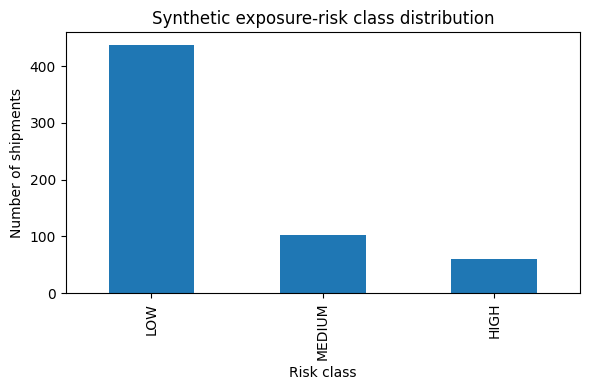

risk_class,HIGH,LOW,MEDIUM
scenario,,,
combined_stress,49,2,39
drone_like_vibration,0,60,0
high_vibration,0,61,19
prolonged_temp_excursion,11,25,44
shock_heavy,0,80,0
short_temp_excursion,0,90,0
stable_cold_chain,0,120,0


In [4]:

risk_counts = shipments["risk_class"].value_counts().reindex(["LOW", "MEDIUM", "HIGH"])
scenario_counts = shipments["scenario"].value_counts()

summary = pd.DataFrame({
    "count": risk_counts,
    "share_%": (risk_counts / len(shipments) * 100).round(1)
})
display(summary)

fig, ax = plt.subplots(figsize=(6,4))
risk_counts.plot(kind="bar", ax=ax)
ax.set_title("Synthetic exposure-risk class distribution")
ax.set_xlabel("Risk class")
ax.set_ylabel("Number of shipments")
plt.tight_layout()
plt.show()

display(pd.crosstab(shipments["scenario"], shipments["risk_class"]))



## 5. Örnek gönderi: sensör geçmişi → maruziyet özeti

Grafikteki 8°C çizgisi **simülasyon içi cold-chain referansıdır**; HRP için evrensel biyolojik hasar sınırı olarak yorumlanmamalıdır.


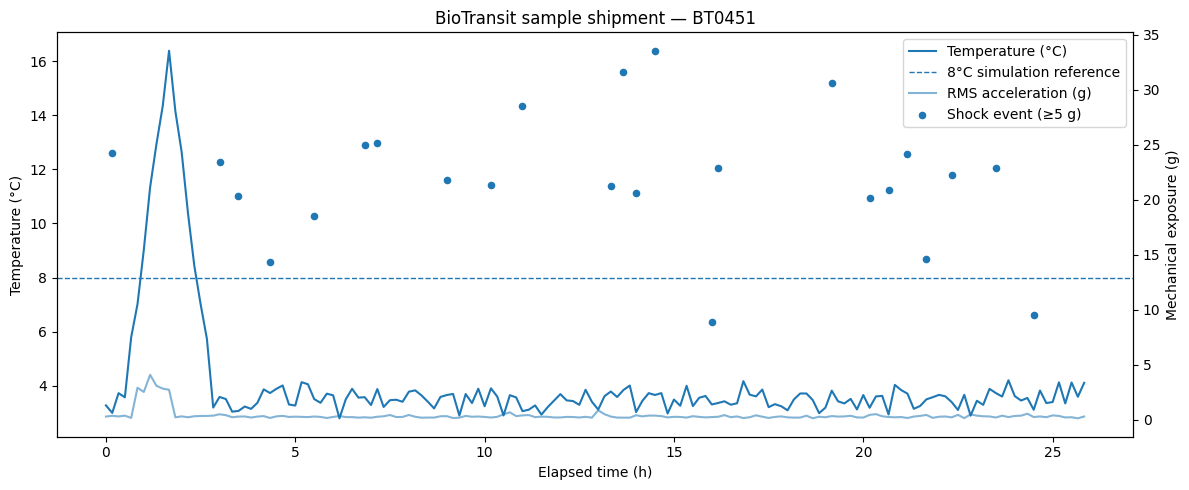

,450
shipment_id,BT0451
scenario,combined_stress
risk_class,MEDIUM
duration_h,26.0
mean_temp_c,4.07692
max_temp_c,16.3828
temp_sd_c,2.162279
time_above_8c_min,90.0
thermal_auc_above_8c_c_h,6.26875
mean_accel_rms_g,0.38671


In [5]:

example_id = shipments.loc[
    shipments["scenario"].eq("combined_stress"), "shipment_id"
].iloc[0]

ex = raw[raw["shipment_id"] == example_id].copy()

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(ex["elapsed_min"]/60, ex["temperature_c"], label="Temperature (°C)")
ax1.axhline(8, linestyle="--", linewidth=1, label="8°C simulation reference")
ax1.set_xlabel("Elapsed time (h)")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()
ax2.plot(
    ex["elapsed_min"]/60, ex["accel_rms_g"],
    alpha=0.55, label="RMS acceleration (g)"
)
shock_mask = ex["shock_peak_g"] >= 5
ax2.scatter(
    ex.loc[shock_mask, "elapsed_min"]/60,
    ex.loc[shock_mask, "shock_peak_g"],
    s=20, label="Shock event (≥5 g)"
)
ax2.set_ylabel("Mechanical exposure (g)")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper right")
plt.title(f"BioTransit sample shipment — {example_id}")
plt.tight_layout()
plt.show()

display(
    shipments.loc[shipments["shipment_id"].eq(example_id),
                  ["shipment_id", "scenario", "risk_class"] + feature_cols].T
)



## 6. Model tasarımı

### Modele VERİLMEYEN kolonlar
- `scenario`
- `literature_informed_risk_score`
- `simulation_integrity_proxy`

Bunlar sentetik veri üretim / audit kolonlarıdır. Modele verilmesi doğrudan target leakage yaratırdı.

### Karşılaştırılan yaklaşımlar
1. **Dummy most-frequent** — sınıf dengesizliği referansı.
2. **Simple threshold** — yalnız max temperature + max shock.
3. **Multivariate logistic regression** — basit, açıklanabilir çok değişkenli baseline.
4. **Random Forest** — non-linear etkileşimleri öğrenen MVP modeli.

> Bu karşılaştırma biyolojik üstünlük kanıtı değildir. Sentetik kural yapısını hangi modelin ne kadar iyi yeniden yakaladığını gösterir.


In [6]:

X = shipments[feature_cols].copy()
y = shipments["risk_class"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=350,
    max_depth=8,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

def threshold_baseline(df):
    out = []
    for _, r in df.iterrows():
        if r["max_temp_c"] > 20 or r["max_shock_g"] >= 30:
            out.append("HIGH")
        elif r["max_temp_c"] > 8 or r["max_shock_g"] >= 15:
            out.append("MEDIUM")
        else:
            out.append("LOW")
    return np.array(out)

threshold_pred = threshold_baseline(X_test)

logit = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight="balanced")
)
logit.fit(X_train, y_train)
logit_pred = logit.predict(X_test)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

def metric_row(name, yt, yp):
    return {
        "model": name,
        "accuracy": accuracy_score(yt, yp),
        "balanced_accuracy": balanced_accuracy_score(yt, yp),
        "macro_f1": f1_score(yt, yp, average="macro")
    }

holdout_metrics = pd.DataFrame([
    metric_row("Dummy most-frequent", y_test, dummy_pred),
    metric_row("Simple threshold", y_test, threshold_pred),
    metric_row("Multivariate logistic", y_test, logit_pred),
    metric_row("Random Forest", y_test, rf_pred),
]).sort_values("macro_f1", ascending=False)

display(holdout_metrics.round(3))

print("\nRandom Forest — class-wise report")
print(classification_report(y_test, rf_pred, digits=3))


,model,accuracy,balanced_accuracy,macro_f1
3,Random Forest,0.907,0.899,0.870
2,Multivariate logistic,0.887,0.889,0.845
1,Simple threshold,0.407,0.557,0.377
0,Dummy most-frequent,0.733,0.333,0.282



Random Forest — class-wise report
              precision    recall  f1-score   support

        HIGH      0.929     0.867     0.897        15
         LOW      0.990     0.909     0.948       110
      MEDIUM      0.657     0.920     0.767        25

    accuracy                          0.907       150
   macro avg      0.859     0.899     0.870       150
weighted avg      0.928     0.907     0.913       150




## 7. 5-fold cross-validation

Tek bir train/test split tesadüfi olarak iyi veya kötü görünebilir. Bu nedenle ana teknik kontrolü 5-fold stratified cross-validation ile tekrar ediyoruz.


In [7]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Dummy most-frequent": DummyClassifier(strategy="most_frequent"),
    "Multivariate logistic": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced")
    ),
    "Decision tree (depth=3)": DecisionTreeClassifier(
        max_depth=3, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=350,
        max_depth=8,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro"
}

cv_rows = []
for name, estimator in models.items():
    res = cross_validate(estimator, X, y, cv=cv, scoring=scoring)
    cv_rows.append({
        "model": name,
        "accuracy_mean": res["test_accuracy"].mean(),
        "accuracy_sd": res["test_accuracy"].std(),
        "balanced_accuracy_mean": res["test_balanced_accuracy"].mean(),
        "balanced_accuracy_sd": res["test_balanced_accuracy"].std(),
        "macro_f1_mean": res["test_macro_f1"].mean(),
        "macro_f1_sd": res["test_macro_f1"].std(),
    })

cv_metrics = pd.DataFrame(cv_rows).sort_values("macro_f1_mean", ascending=False)
display(cv_metrics.round(3))


,model,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd
1,Multivariate logistic,0.927,0.006,0.910,0.022,0.882,0.016
3,Random Forest,0.915,0.025,0.849,0.074,0.845,0.060
2,Decision tree (depth=3),0.813,0.033,0.766,0.035,0.730,0.038
0,Dummy most-frequent,0.730,0.004,0.333,0.000,0.281,0.001



## 8. Confusion matrix ve permutation importance

Permutation importance, klasik impurity-based feature importance'a göre test setindeki performans düşüşünü ölçtüğü için jüri karşısında daha anlaşılır bir yorum sunar.

**Yine:** importance = sentetik risk kurgusunu ayırmada hangi feature'ın faydalı olduğu. Biyolojik nedensellik değildir.


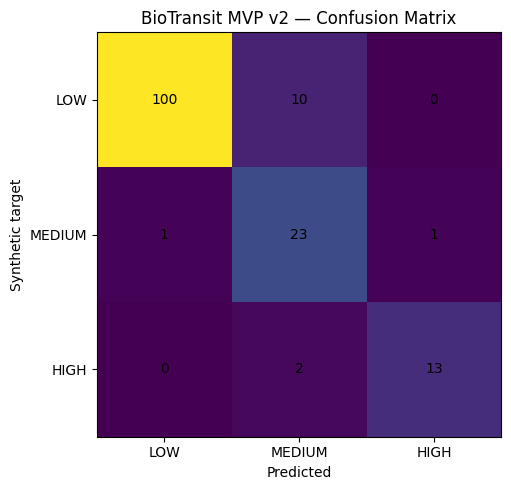

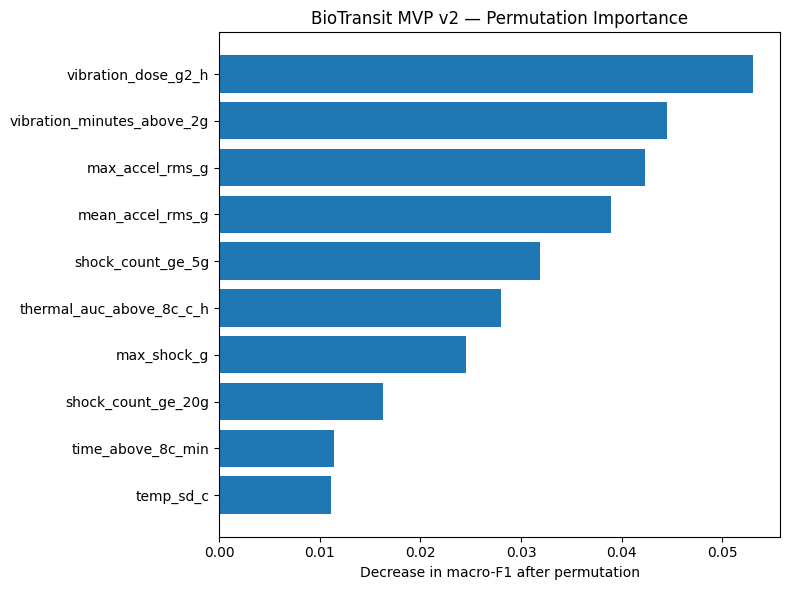

,feature,importance_mean,importance_sd
9,vibration_dose_g2_h,0.0531,0.0163
8,vibration_minutes_above_2g,0.0445,0.0130
7,max_accel_rms_g,0.0424,0.0112
6,mean_accel_rms_g,0.0389,0.0138
11,shock_count_ge_5g,0.0319,0.0101
5,thermal_auc_above_8c_c_h,0.0280,0.0188
13,max_shock_g,0.0245,0.0127
12,shock_count_ge_20g,0.0162,0.0126
4,time_above_8c_min,0.0115,0.0166
3,temp_sd_c,0.0111,0.0210


In [8]:

labels = ["LOW", "MEDIUM", "HIGH"]
cm = confusion_matrix(y_test, rf_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm)
ax.set_xticks(range(3), labels=labels)
ax.set_yticks(range(3), labels=labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Synthetic target")
ax.set_title("BioTransit MVP v2 — Confusion Matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

perm = permutation_importance(
    rf, X_test, y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE
)

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_sd": perm.importances_std
}).sort_values("importance_mean", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(importance["feature"], importance["importance_mean"])
ax.set_xlabel("Decrease in macro-F1 after permutation")
ax.set_title("BioTransit MVP v2 — Permutation Importance")
plt.tight_layout()
plt.show()

display(importance.sort_values("importance_mean", ascending=False).round(4))



## 9. Scenario-holdout stress test — önemli öğrenim

Random split, aynı sentetik scenario generator'ından gelen benzer örnekleri train ve test'e dağıtır.  
Bu nedenle ikinci bir test yapıyoruz: **bir scenario tamamen görülmeden bırakılıyor** ve model kalan scenario'larla eğitiliyor.

Bu test product validation değildir; sentetik datasetin ne kadar kırılgan olabileceğini göstermek için eklenmiştir. Özellikle `combined_stress` veya `prolonged_temp_excursion` gibi görülmemiş karmaşık stress pattern'larında performans düşerse, bu **PoC dataset tasarımının daha çeşitli mixed-stress koşulları içermesi gerektiğini** söyler.


In [9]:

logo = LeaveOneGroupOut()
groups = shipments["scenario"]

scenario_rows = []

for train_idx, test_idx in logo.split(X, y, groups=groups):
    held_out = groups.iloc[test_idx].iloc[0]

    m = RandomForestClassifier(
        n_estimators=350,
        max_depth=8,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    p = m.predict(X.iloc[test_idx])

    scenario_rows.append({
        "held_out_scenario": held_out,
        "n": len(test_idx),
        "classes_in_test": ", ".join(sorted(y.iloc[test_idx].unique())),
        "accuracy": accuracy_score(y.iloc[test_idx], p),
        "macro_f1_all_3_classes": f1_score(
            y.iloc[test_idx], p,
            labels=["LOW", "MEDIUM", "HIGH"],
            average="macro",
            zero_division=0
        )
    })

scenario_holdout = pd.DataFrame(scenario_rows)
display(scenario_holdout.round(3))

print(
    "\nInterpretation: Random-split metrikleri pipeline tutarlılığını gösterir; "
    "scenario-holdout düşüşleri gerçek dünya genellemesi iddiası yapmamamız gerektiğini doğrular."
)


,held_out_scenario,n,classes_in_test,accuracy,macro_f1_all_3_classes
0,combined_stress,90,"HIGH, LOW, MEDIUM",0.078,0.068
1,drone_like_vibration,60,LOW,1.000,0.333
2,high_vibration,80,"LOW, MEDIUM",0.762,0.288
3,prolonged_temp_excursion,80,"HIGH, LOW, MEDIUM",0.312,0.159
4,shock_heavy,80,LOW,1.000,0.333
5,short_temp_excursion,90,LOW,0.911,0.318
6,stable_cold_chain,120,LOW,1.000,0.333



Interpretation: Random-split metrikleri pipeline tutarlılığını gösterir; scenario-holdout düşüşleri gerçek dünya genellemesi iddiası yapmamamız gerektiğini doğrular.



## 10. Jüri demo fonksiyonu: tek gönderiyi açıklanabilir çıktıya çevir

`predict_proba` değeri burada **kalibre edilmiş güven skoru değildir**. Bu yüzden çıktı `uncalibrated_class_probability` olarak adlandırılır.


In [10]:

def jury_demo(shipment_id: str):
    row = shipments.loc[shipments["shipment_id"].eq(shipment_id)]
    if row.empty:
        raise ValueError(f"Unknown shipment_id: {shipment_id}")

    X_row = row[feature_cols]
    pred = rf.predict(X_row)[0]
    probs = pd.Series(
        rf.predict_proba(X_row)[0],
        index=rf.classes_
    ).sort_values(ascending=False)

    profile = {
        "shipment_id": shipment_id,
        "prototype_exposure_risk": pred,
        "uncalibrated_class_probability": round(float(probs.iloc[0]), 3),
        "max_temp_c": round(float(row["max_temp_c"].iloc[0]), 2),
        "time_above_8c_min": round(float(row["time_above_8c_min"].iloc[0]), 1),
        "thermal_auc_above_8c_c_h": round(float(row["thermal_auc_above_8c_c_h"].iloc[0]), 2),
        "max_accel_rms_g": round(float(row["max_accel_rms_g"].iloc[0]), 2),
        "vibration_minutes_above_2g": round(float(row["vibration_minutes_above_2g"].iloc[0]), 1),
        "shock_count_ge_20g": int(row["shock_count_ge_20g"].iloc[0]),
        "max_shock_g": round(float(row["max_shock_g"].iloc[0]), 2),
    }

    print("=== BioTransit AI — Prototype shipment summary ===")
    for k, v in profile.items():
        print(f"{k:35s}: {v}")

    print("\nClass probabilities (uncalibrated):")
    display(probs.rename("probability").to_frame().round(3))

    print(
        "\nSCIENTIFIC NOTICE: This is an exposure-risk prototype output, "
        "not a biological activity assay result and not a release/use decision."
    )

jury_demo(example_id)


=== BioTransit AI — Prototype shipment summary ===
shipment_id                        : BT0451
prototype_exposure_risk            : MEDIUM
uncalibrated_class_probability     : 0.811
max_temp_c                         : 16.38
time_above_8c_min                  : 90.0
thermal_auc_above_8c_c_h           : 6.27
max_accel_rms_g                    : 4.08
vibration_minutes_above_2g         : 60.0
shock_count_ge_20g                 : 19
max_shock_g                        : 33.54

Class probabilities (uncalibrated):


,probability
MEDIUM,0.811
HIGH,0.148
LOW,0.040



SCIENTIFIC NOTICE: This is an exposure-risk prototype output, not a biological activity assay result and not a release/use decision.



## 11. Ne kanıtlandı / ne kanıtlanmadı?

### Bu prototipin gösterdiği
- Ham sensör benzeri time-series verisi işlenebiliyor.
- Gönderi bazında termal + mekanik feature pipeline'ı çalışıyor.
- Çok değişkenli sınıflandırma pipeline'ı çalışıyor.
- Sentetik literature-informed target üzerinde Random Forest, basit threshold ve dummy yaklaşımlardan daha güçlü ayrım yapabiliyor.
- Scenario-holdout testi, genelleme limitini görünür kılıyor.

### Bu prototipin göstermediği
- HRP'nin gerçek kalan aktivitesi.
- Bir proteinin kullanılabilir / kullanılamaz olduğuna dair klinik veya kalite kararı.
- GMP/GDP release kararı.
- Başka proteinlere doğrudan transfer edilebilir biyolojik doğruluk.
- %94 gibi bir sayının “gerçek dünyada %94 doğru biyolojik tahmin” olduğu.

### Sonraki PoC
1. Temperature sensor + 3-axis/6-axis IMU + logger.
2. Kontrollü thermal / vibration / shock exposure.
3. Ticari HRP örnekleri.
4. Guaiacol / ABTS / TMB tabanlı activity assay ile gerçek `residual_activity_%`.
5. Shipment sensor trace ↔ assay sonucu eşleme.
6. Regression + risk classification model recalibration.
7. Gerçek held-out deney koşullarıyla validation.



## 12. CDR için güvenli sonuç cümlesi

> **PDR sonrasında BioTransit AI'nin ilk çalışan software prototype'ı geliştirilmiştir. Ham sensör benzeri zaman serilerinden termal ve mekanik maruziyet feature'ları çıkarılmakta ve çok değişkenli model, literature-informed sentetik simulation datasetinde LOW–MEDIUM–HIGH exposure-risk ayrımı yapmaktadır. Random Forest, basit threshold yaklaşımına göre daha güçlü ayrım göstermiştir; ancak mevcut target gerçek biyolojik assay sonucu olmadığı için bu metrikler biyolojik doğruluk olarak yorumlanmamaktadır. Scenario-holdout analizi de sentetik veriyle gerçek dünya genellemesi iddiası yapılamayacağını göstermiştir. Sonraki PoC aşamasında HRP activity assay sonuçları gerçek ground-truth olarak modele bağlanacaktır.**


In [11]:

# Optional export: CDR appendix / report tables
holdout_metrics.to_csv("BioTransit_CDR_v2_holdout_metrics.csv", index=False)
cv_metrics.to_csv("BioTransit_CDR_v2_cross_validation_metrics.csv", index=False)
scenario_holdout.to_csv("BioTransit_CDR_v2_scenario_holdout.csv", index=False)

print("Exported:")
print("- BioTransit_CDR_v2_holdout_metrics.csv")
print("- BioTransit_CDR_v2_cross_validation_metrics.csv")
print("- BioTransit_CDR_v2_scenario_holdout.csv")


Exported:
- BioTransit_CDR_v2_holdout_metrics.csv
- BioTransit_CDR_v2_cross_validation_metrics.csv
- BioTransit_CDR_v2_scenario_holdout.csv
